In [4]:
pip install -U langchain umap-learn scikit-learn langchain_community tiktoken langchain-openai langchainhub langchain-chroma langchain-anthropic matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 7.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Matplotlib is building the font cache; this may take a moment.
/var/folders/rh/fs8qsd7x217_g3vxvdjg8dxc0000gn/T/ipykernel_3077/171049657.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader


<function matplotlib.pyplot.show(close=None, block=None)>

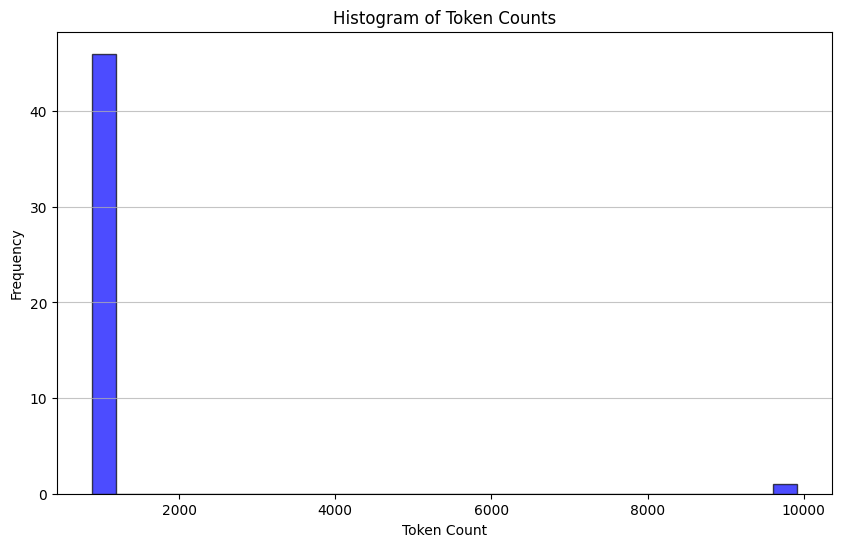

In [ ]:
import matplotlib.pyplot as plt
import tiktoken
from bs4 import BeautifulSoup as Soup
from langchain_community.document_loaders.recursive_url_loader import RecursiveUrlLoader


def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    # get_encoding() returns a Encoding object which has an encode() method that converts a string into a list of tokens
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens


# LCEL docs
url = "https://python.langchain.com/docs/expression_language/"
# We use the text content of the page as the document content, but you could also use the raw HTML or other formats if desired.
# Note that we set max_depth to 20 to ensure we capture all linked pages within the LCEL docs, but you can adjust this as needed.
# The extractor function uses BeautifulSoup to parse the HTML and extract the text content, which is what we want for our documents.
# Note that this will only extract the text content of the page, so any images, code snippets, or other non-text content will not be included in the documents. If you want to include those as well, you would need to modify the extractor function accordingly.
# RecursiveUrlLoader will follow links within the specified URL up to the max_depth, allowing us to capture the entire LCEL documentation site.
# max_depth=20 is set to ensure we capture all linked pages within the LCEL docs, but you can adjust this as needed based on the structure of the site and how many levels of links you want to follow.
# max_depth levels means that the loader will follow links up to 20 levels deep from the initial URL. This should be sufficient to capture the entire LCEL documentation site, but you can adjust this as needed based on the structure of the site and how many levels of links you want to follow.
# what is level in this context? Level refers to the depth of links followed from the initial URL. For example, if the initial URL is level 0, then any page linked directly from that URL would be level 1, any page linked from a level 1 page would be level 2, and so on. Setting max_depth to 20 means that the loader will follow links up to 20 levels deep from the initial URL.
loader = RecursiveUrlLoader(
    url=url, max_depth=20, extractor=lambda x: Soup(x, "html.parser").text
)
# loader.load() will start the loading process, following links and extracting text content from each page until it reaches the max_depth or runs out of links to follow. The result will be a list of documents, where each document corresponds to a page in the LCEL documentation site and contains the text content of that page.
docs = loader.load()

# LCEL w/ PydanticOutputParser (outside the primary LCEL docs)
url = "https://python.langchain.com/docs/modules/model_io/output_parsers/quick_start"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_pydantic = loader.load()

# LCEL w/ Self Query (outside the primary LCEL docs)
url = "https://python.langchain.com/docs/modules/data_connection/retrievers/self_query/"
loader = RecursiveUrlLoader(
    url=url, max_depth=1, extractor=lambda x: Soup(x, "html.parser").text
)
docs_sq = loader.load()

# Doc texts
docs.extend([*docs_pydantic, *docs_sq])
docs_texts = [d.page_content for d in docs]

# Calculate the number of tokens for each document
counts = [num_tokens_from_string(d, "cl100k_base") for d in docs_texts]

# Plotting the histogram of token counts
plt.figure(figsize=(10, 6))
plt.hist(counts, bins=30, color="blue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Token Counts")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.75)

# Display the histogram
plt.show